# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import joblib

# 2. Load Dataset

In [2]:
df = pd.read_csv("loan_approval_data.csv")

# 3. Initial Data Understanding

In [3]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

In [5]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [6]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# 4. Exploratory Data Analysis (EDA)

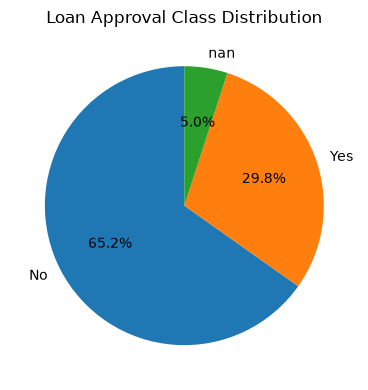

In [7]:
# Target class distribution
classes_count = df["Loan_Approved"].value_counts(dropna=False)
plt.figure(figsize=(6, 4))
plt.pie(classes_count.dropna(), labels=classes_count.dropna().index, autopct="%1.1f%%", startangle=90)
plt.title("Loan Approval Class Distribution")
plt.tight_layout()
plt.show()

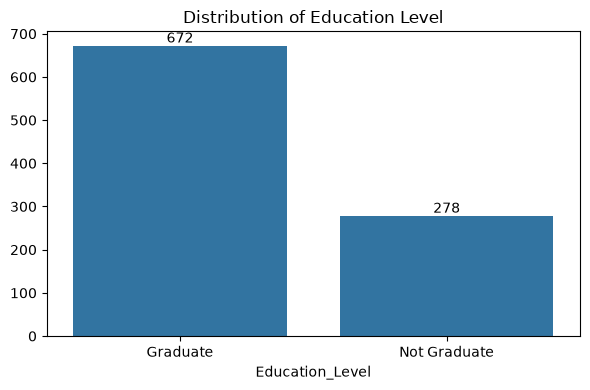

In [8]:
# Education Level distribution
plt.figure(figsize=(6, 4))
edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(x=edu_cnt.index, y=edu_cnt.values)
ax.bar_label(ax.containers[0])
plt.title("Distribution of Education Level")
plt.tight_layout()
plt.show()

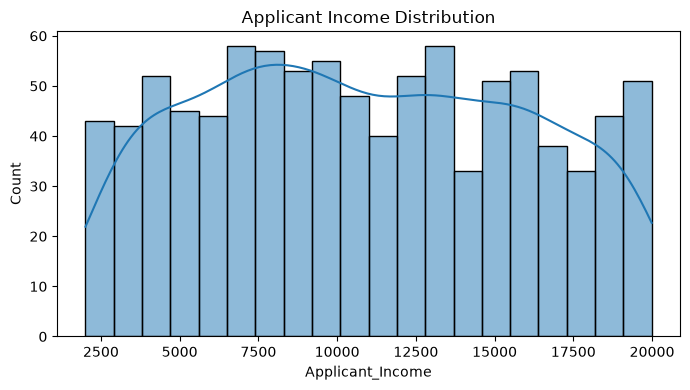

In [9]:
# Applicant Income distribution
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="Applicant_Income", bins=20, kde=True)
plt.title("Applicant Income Distribution")
plt.tight_layout()
plt.show()

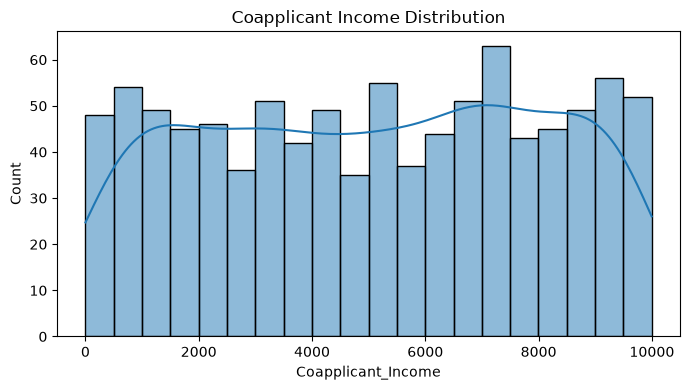

In [10]:
# Coapplicant Income distribution
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="Coapplicant_Income", bins=20, kde=True)
plt.title("Coapplicant Income Distribution")
plt.tight_layout()
plt.show()

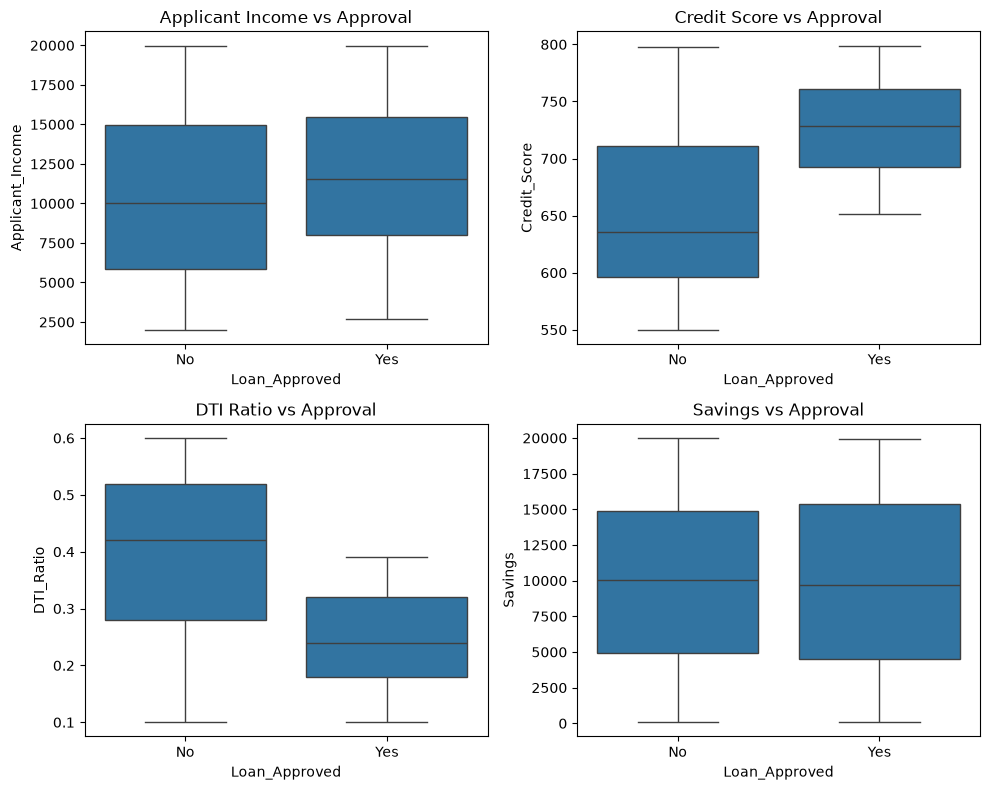

In [11]:
# Key numerical features by Loan Approval status
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.boxplot(ax=axes[0, 0], data=df, x="Loan_Approved", y="Applicant_Income")
axes[0, 0].set_title("Applicant Income vs Approval")

sns.boxplot(ax=axes[0, 1], data=df, x="Loan_Approved", y="Credit_Score")
axes[0, 1].set_title("Credit Score vs Approval")

sns.boxplot(ax=axes[1, 0], data=df, x="Loan_Approved", y="DTI_Ratio")
axes[1, 0].set_title("DTI Ratio vs Approval")

sns.boxplot(ax=axes[1, 1], data=df, x="Loan_Approved", y="Savings")
axes[1, 1].set_title("Savings vs Approval")

plt.tight_layout()
plt.show()

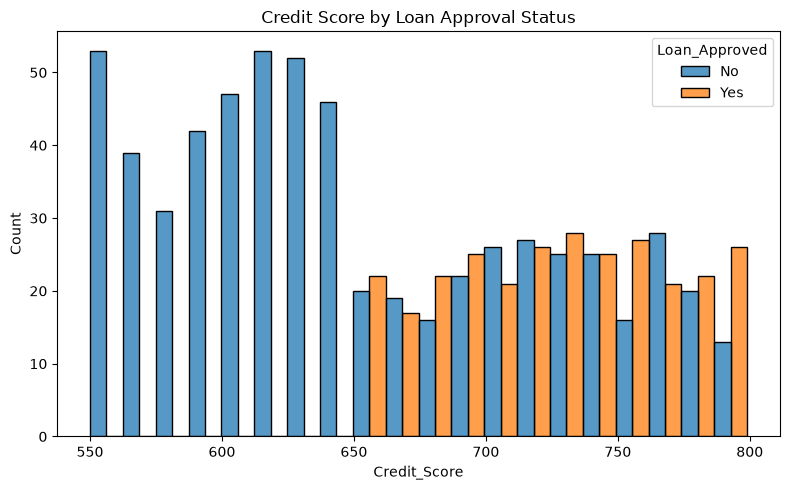

In [12]:
# Credit Score distribution grouped by Loan Approval
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Credit_Score", hue="Loan_Approved", bins=20, multiple="dodge")
plt.title("Credit Score by Loan Approval Status")
plt.tight_layout()
plt.show()

# 5. Data Cleaning & Separate Features and Target
We remove rows missing the target variable (`Loan_Approved`) and drop the non-predictive identifier `Applicant_ID`.

In [13]:
# Drop missing target rows and remove non-predictive identifier
df = df.dropna(subset=["Loan_Approved"]).copy()
df = df.drop("Applicant_ID", axis=1)

# Encode binary target: 'No' -> 0, 'Yes' -> 1
df["Loan_Approved"] = df["Loan_Approved"].map({"No": 0, "Yes": 1})

X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

print(f"Features shape: {X.shape}, Target distribution:\n{y.value_counts()}")

Features shape: (950, 18), Target distribution:
Loan_Approved
0    652
1    298
Name: count, dtype: int64


# 6. Train-Test Split (Held-Out Test Set)
To prevent data leakage, we partition the dataset into training (80%) and held-out test (20%) sets before any preprocessing or modeling.
All cross-validation and hyperparameter tuning strictly use `X_train`. The held-out test set `X_test` is reserved for a single final evaluation.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

X_train shape: (760, 18), y_train shape: (760,)
X_test shape:  (190, 18), y_test shape:  (190,)


### Correlation Analysis on Training Set
We inspect linear correlations exclusively on the training set to prevent data leakage.

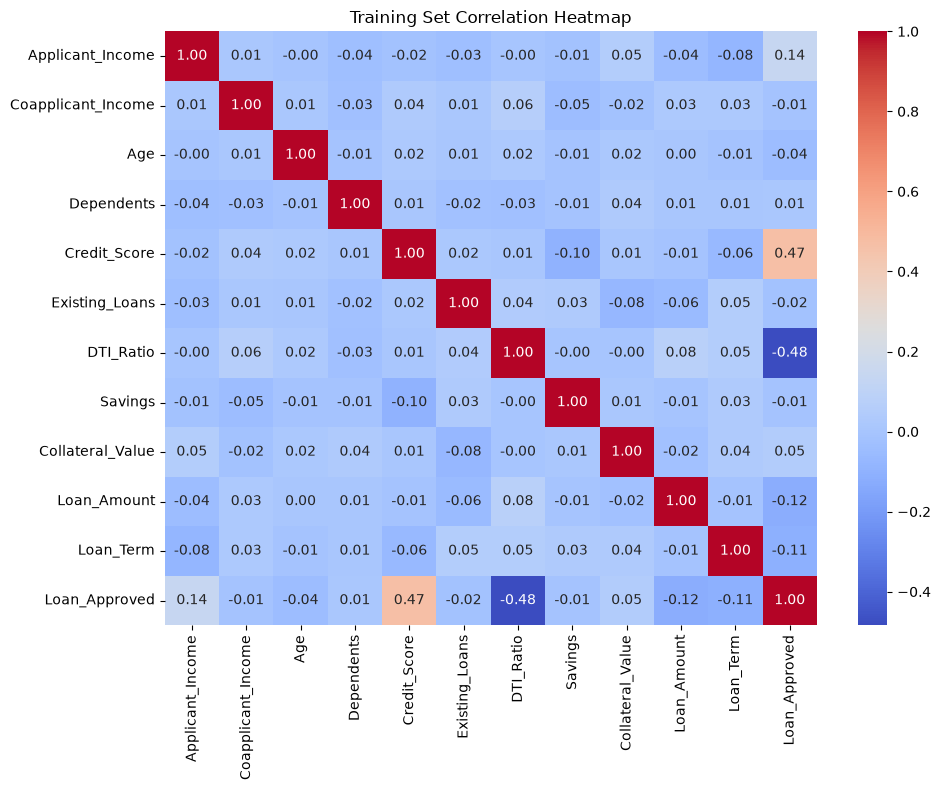

Correlation with Loan_Approved:
Loan_Approved         1.000000
Credit_Score          0.469220
Applicant_Income      0.138800
Collateral_Value      0.047812
Dependents            0.012466
Coapplicant_Income   -0.010399
Savings              -0.011793
Existing_Loans       -0.019660
Age                  -0.044884
Loan_Term            -0.108093
Loan_Amount          -0.123218
DTI_Ratio            -0.484086
Name: Loan_Approved, dtype: float64


In [15]:
numerical_cols = X_train.select_dtypes(include="number").columns
train_corr_data = pd.concat([X_train[numerical_cols], y_train.rename("Loan_Approved")], axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(train_corr_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Training Set Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Correlation with Loan_Approved:")
print(train_corr_data.corr()["Loan_Approved"].sort_values(ascending=False))

# 7. Define Feature Types
We identify numerical, ordinal, and nominal feature columns.
All missing value imputation and scaling/encoding transformations are encapsulated directly inside the scikit-learn preprocessing pipeline, eliminating redundant external preprocessing.

In [16]:
numerical_cols = X.select_dtypes(include="number").columns.tolist()
categorical_cols = X.select_dtypes(exclude="number").columns.tolist()

ordinal_cols = ["Education_Level"]
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

print("Numerical columns (11):", numerical_cols)
print("Ordinal columns (1):", ordinal_cols)
print("Nominal columns (6):", nominal_cols)

Numerical columns (11): ['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term']
Ordinal columns (1): ['Education_Level']
Nominal columns (6): ['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area', 'Gender', 'Employer_Category']


# 8. Build Preprocessing Pipelines
We construct modular scikit-learn Pipelines:
- **Numerical Pipeline**: Mean imputation followed by standard scaling (`StandardScaler`).
- **Ordinal Pipeline**: Most frequent imputation followed by ordinal encoding (`OrdinalEncoder`) for education level.
- **Nominal Pipeline**: Most frequent imputation followed by one-hot encoding (`OneHotEncoder(drop="first", handle_unknown="ignore")`).
- **ColumnTransformer**: Combines all three pipelines with `remainder="drop"` to cleanly drop any extraneous columns during inference.

In [17]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

education_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=[["Not Graduate", "Graduate"]]))
])

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_cols),
    ("edu", education_pipeline, ordinal_cols),
    ("cat", nominal_pipeline, nominal_cols)
], remainder="drop")

# 9. Baseline Models & 5-Fold Cross-Validation
We evaluate the three core models (Logistic Regression, KNN, and Gaussian Naive Bayes) using 5-fold stratified cross-validation on the training set.
In accordance with project requirements, **F1 score** is our primary evaluation metric, with accuracy reported alongside it.

In [18]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['Applicant_Income','Coapplicant_Income','Employment_Status',..., 'Education_Level','Gender','Employer_Category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('edu', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [19]:
logistic_cv_f1 = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Logistic Regression")
print("CV F1 scores:", logistic_cv_f1)
print("Mean CV F1:", logistic_cv_f1.mean())
print("Standard Deviation:", logistic_cv_f1.std())

Logistic Regression
CV F1 scores: [0.80434783 0.72916667 0.80434783 0.7816092  0.74468085]
Mean CV F1: 0.7728304730613417
Standard Deviation: 0.03086318926130792


In [20]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['Applicant_Income','Coapplicant_Income','Employment_Status',..., 'Education_Level','Gender','Employer_Category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('edu', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [21]:
knn_cv_f1 = cross_val_score(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("KNN")
print("CV F1 scores:", knn_cv_f1)
print("Mean CV F1:", knn_cv_f1.mean())
print("Standard Deviation:", knn_cv_f1.std())

KNN
CV F1 scores: [0.72340426 0.69662921 0.76767677 0.70212766 0.76086957]
Mean CV F1: 0.7301414922541845
Standard Deviation: 0.029347399818161337


In [22]:
nb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])

nb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['Applicant_Income','Coapplicant_Income','Employment_Status',..., 'Education_Level','Gender','Employer_Category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('edu', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [23]:
nb_cv_f1 = cross_val_score(
    nb_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Naive Bayes")
print("CV F1 scores:", nb_cv_f1)
print("Mean CV F1:", nb_cv_f1.mean())
print("Standard Deviation:", nb_cv_f1.std())

Naive Bayes
CV F1 scores: [0.76190476 0.71910112 0.81818182 0.85714286 0.71910112]
Mean CV F1: 0.7750863368840897
Standard Deviation: 0.05483235387639769


In [24]:
baseline_results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Naive Bayes"
    ],
    "CV F1 (Mean)": [
        logistic_cv_f1.mean(),
        knn_cv_f1.mean(),
        nb_cv_f1.mean()
    ],
    "CV F1 (Std)": [
        logistic_cv_f1.std(),
        knn_cv_f1.std(),
        nb_cv_f1.std()
    ]
})

baseline_results_df

,Model,CV F1 (Mean),CV F1 (Std)
0,Logistic Regression,0.772830,0.030863
1,KNN,0.730141,0.029347
2,Naive Bayes,0.775086,0.054832


# 10. Hyperparameter Tuning (GridSearchCV with scoring="f1")
We tune hyperparameters for all three models using 5-fold cross-validation on `X_train` using `scoring="f1"` as the selection criterion.

In [25]:
# Logistic Regression tuning
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

logistic_pipe = Pipeline([("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=1000, random_state=42))])
logistic_grid = GridSearchCV(logistic_pipe, param_grid=logistic_param_grid, cv=5, scoring="f1")
logistic_grid.fit(X_train, y_train)

print("Logistic Regression Best Parameters:", logistic_grid.best_params_)
print("Logistic Regression Best CV F1:", f"{logistic_grid.best_score_:.4f}")

Logistic Regression Best Parameters: {'model__C': 1}
Logistic Regression Best CV F1: 0.7728


In [26]:
# KNN tuning
knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15]
}

knn_pipe = Pipeline([("preprocessor", preprocessor), ("model", KNeighborsClassifier())])
knn_grid = GridSearchCV(knn_pipe, param_grid=knn_param_grid, cv=5, scoring="f1")
knn_grid.fit(X_train, y_train)

print("KNN Best Parameters:", knn_grid.best_params_)
print("KNN Best CV F1:", f"{knn_grid.best_score_:.4f}")

KNN Best Parameters: {'model__n_neighbors': 15}
KNN Best CV F1: 0.7475


In [27]:
# Naive Bayes tuning
nb_param_grid = {
    "model__var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}

nb_pipe = Pipeline([("preprocessor", preprocessor), ("model", GaussianNB())])
nb_grid = GridSearchCV(nb_pipe, param_grid=nb_param_grid, cv=5, scoring="f1")
nb_grid.fit(X_train, y_train)

print("Naive Bayes Best Parameters:", nb_grid.best_params_)
print("Naive Bayes Best CV F1:", f"{nb_grid.best_score_:.4f}")

Naive Bayes Best Parameters: {'model__var_smoothing': 1e-11}
Naive Bayes Best CV F1: 0.7751


### Model Comparison after Tuning

In [28]:
tuning_comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Best Parameters": str(logistic_grid.best_params_),
        "Best CV F1": logistic_grid.best_score_
    },
    {
        "Model": "KNN",
        "Best Parameters": str(knn_grid.best_params_),
        "Best CV F1": knn_grid.best_score_
    },
    {
        "Model": "Naive Bayes",
        "Best Parameters": str(nb_grid.best_params_),
        "Best CV F1": nb_grid.best_score_
    }
])
tuning_comparison_df.sort_values("Best CV F1", ascending=False)

,Model,Best Parameters,Best CV F1
2,Naive Bayes,{'model__var_smoothing': 1e-11},0.775086
0,Logistic Regression,{'model__C': 1},0.772830
1,KNN,{'model__n_neighbors': 15},0.747506


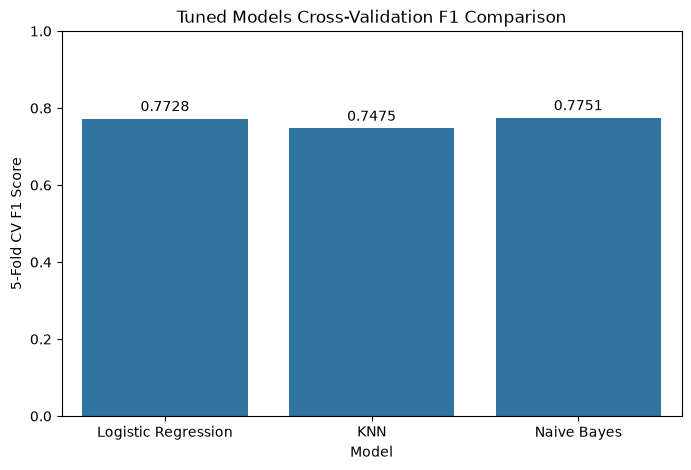

In [29]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=tuning_comparison_df, x="Model", y="Best CV F1")

plt.title("Tuned Models Cross-Validation F1 Comparison")
plt.ylabel("5-Fold CV F1 Score")
plt.ylim(0, 1)

ax.bar_label(ax.containers[0], fmt="%.4f", padding=3)

plt.show()

# 11. Final Model Selection
**Logistic Regression** (`C=1`) is selected as the final production model for the following reasons:
1. **Strong and Consistent CV Score**: Achieved a cross-validation F1 score of **0.7728** on the training set with low variance across folds (std = 0.031).
2. **Calibrated Probabilities**: Produces well-calibrated class probabilities, which are essential for credit risk thresholding and lending decisions (unlike Naive Bayes, whose conditional independence assumptions distort probabilities).
3. **Interpretability**: Features linear odds-ratio coefficients, providing transparency into how individual applicant characteristics influence the predicted outcome.

# 12. Final Evaluation on Held-Out Test Set
In accordance with strict train/CV/test discipline, we now perform **one final evaluation** of the selected Logistic Regression model on the held-out test set (`X_test`).

In [30]:
final_pipeline = logistic_grid.best_estimator_

# Generate test set predictions
y_pred_final = final_pipeline.predict(X_test)

final_test_metrics = pd.DataFrame([{
    "Model": "Logistic Regression (Final)",
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final),
    "Recall": recall_score(y_test, y_pred_final),
    "F1 Score": f1_score(y_test, y_pred_final)
}])
final_test_metrics

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Final),0.889474,0.854545,0.783333,0.817391


# 13. Confusion Matrix Display

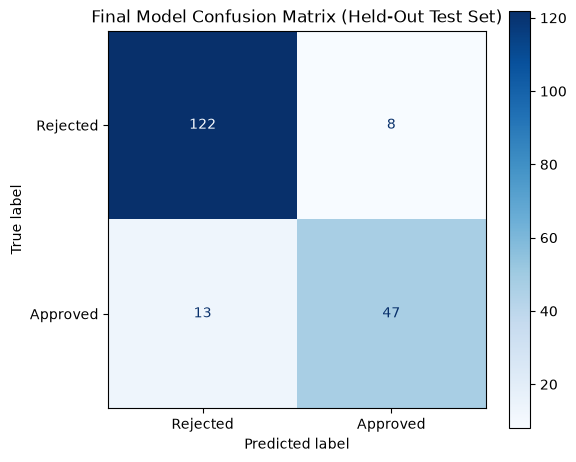

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=["Rejected", "Approved"],
    cmap="Blues",
    ax=ax
)
plt.title("Final Model Confusion Matrix (Held-Out Test Set)")
plt.tight_layout()
plt.show()

# 14. Save Final Pipeline to `model.pkl`
We serialize the complete, leak-free scikit-learn pipeline (including imputation, scaling, one-hot/ordinal encoding, and the final Logistic Regression model).

In [32]:
# Save complete pipeline
joblib.dump(final_pipeline, "model.pkl")
print("Saved final pipeline to model.pkl successfully!")

Saved final pipeline to model.pkl successfully!


# 15. Conclusion
This project completed a clean, leak-free, and interview-defensible supervised classification workflow for loan approval prediction:
- **Data Preprocessing**: Implemented a leak-free scikit-learn pipeline using `ColumnTransformer` with `SimpleImputer`, `StandardScaler`, and `OneHotEncoder` / `OrdinalEncoder`.
- **Feature Set**: Retained the original 18 clean, domain-meaningful features, completely avoiding structural multicollinearity and external preprocessing dependencies.
- **Model Tuning**: Evaluated and tuned Logistic Regression, KNN, and Gaussian Naive Bayes using 5-fold cross-validation with **F1 score** as the optimization metric.
- **Final Model Selection**: Selected **Logistic Regression** (`C=1`) for its balanced performance, probability calibration, and financial explainability.
- **Final Held-Out Test Performance**:
  - Accuracy: **88.95%**
  - Precision: **85.45%**
  - Recall: **78.33%**
  - F1 Score: **81.74%**

The complete pipeline was exported to `model.pkl` and is ready for production deployment with Streamlit.